# 2.4 — Обучение DPI-EVT

**Папка 2 «Обучение», подноутбук 4.** DPI-EVT — гибрид: энкодер DPI-Flow выводит латент θ, из
которого строится **развязанная (decoupled)** граница CRR и траектория PPR(N), а число циклов
до разжижения берётся **из самой кривой CRR** (`nliq_from_curve=True`). Это даёт лучший в
проекте предиктор N_liq и устойчивую физику (нулевые нарушения).

Раньше DPI-EVT обучался отдельным скриптом `run_dpievt.py` и не имел своего ноутбука — из-за
чего при чистой папке `models/` он терял веса и выпадал из оценки. Этот ноутбук **штатно**
обучает, калибрует и сохраняет DPI-EVT, повторяя ту же процедуру:

* фиксированный seed, **косинусный планировщик LR** (`scheduler="cosine"`) — ключ к качеству;
* развязанная CRR + N_liq из кривой, без traj-residual и без внутренней калибровки θ;
* пост-hoc калибровка ширины интервалов (`fit_interval_scale`).

> Важно: качество DPI-EVT чувствительно к косинусному расписанию LR — обычный прогон
> `train_model` без планировщика заметно его ухудшает.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch
from liquefaction_ai import (get_default_config, load_population_artifact,
                             prepare_benchmark_dataset, train_model)
from liquefaction_ai.training import write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, fit_interval_scale
from liquefaction_ai.models import DPIEvtNet

config = get_default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
population, config = load_population_artifact(DATA_DIR)
benchmark = prepare_benchmark_dataset(population, config, device)
train, val, test = benchmark["train"], benchmark["val"], benchmark["test"]
static_dim = train["static"].shape[1]; prefix_dim = train["prefix_summary"].shape[1]
seq_dim = train["seq_in"].shape[-1]
print("Источник:", DATA_DIR.name, "| train/val/test:",
      train["static"].shape[0], val["static"].shape[0], test["static"].shape[0],
      "| static_dim:", static_dim)

Источник: demo_run | train/val/test: 466 99 101 | static_dim: 34


## Шаг 1. Конфигурация и сборка модели

Параметры DPI-EVT соответствуют рабочей конфигурации: развязанная CRR, N_liq из кривой,
вероятностная голова и flow, без traj-residual и без внутренней калибровки θ.

In [2]:
model_kwargs = dict(
    static_dim=static_dim, prefix_dim=prefix_dim, seq_dim=seq_dim,
    seq_len=config.seq_len, prefix_len=config.prefix_len,
    max_cycle_reference=config.max_cycle_reference,
    probabilistic=True, use_flow=True,
    crr_mode="decoupled", nliq_from_curve=True,
    calibration_steps=0, use_traj_residual=False,
)
EPOCHS = config.physics_epochs
torch.manual_seed(0)
model = DPIEvtNet(**model_kwargs).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("DPI-EVT параметров:", f"{n_params:,}", "| эпох:", EPOCHS)

DPI-EVT параметров: 213,632 | эпох: 6


## Шаг 2. Обучение с косинусным планировщиком LR

Это ключевой момент: косинусное расписание шага обучения существенно улучшает сходимость
DPI-EVT по сравнению с обычным прогоном.

In [3]:
model, history = train_model(model, train, val, epochs=EPOCHS, model_name="DPI-EVT",
                             config=config, device=device, track_metrics=True,
                             scheduler="cosine", ema_decay=0.0)
display(history)

[DPI-EVT] эпоха 01 | обучение=5.2622 | валидация=1.0590 | val_AUROC=0.988 | val_RMSE=0.3081


[DPI-EVT] эпоха 02 | обучение=0.3915 | валидация=-0.5432 | val_AUROC=0.997 | val_RMSE=0.1997


[DPI-EVT] эпоха 03 | обучение=-0.7180 | валидация=-1.0498 | val_AUROC=0.999 | val_RMSE=0.1531


[DPI-EVT] эпоха 04 | обучение=-1.0368 | валидация=-1.2159 | val_AUROC=0.999 | val_RMSE=0.1412


[DPI-EVT] эпоха 05 | обучение=-1.1922 | валидация=-1.3078 | val_AUROC=1.000 | val_RMSE=0.1338


[DPI-EVT] эпоха 06 | обучение=-1.3007 | валидация=-1.3372 | val_AUROC=1.000 | val_RMSE=0.1300


,epoch,train_loss,val_loss,val_auroc,val_brier,val_traj_rmse
0,1,5.262237,1.059011,0.987607,0.188083,0.308132
1,2,0.391455,-0.543240,0.996581,0.113200,0.199670
2,3,-0.717954,-1.049819,0.998718,0.042134,0.153082
3,4,-1.036769,-1.215910,0.999145,0.019995,0.141199
4,5,-1.192222,-1.307802,0.999573,0.018677,0.133796
5,6,-1.300748,-1.337186,0.999573,0.030670,0.129962


## Шаг 3. Кривые обучения

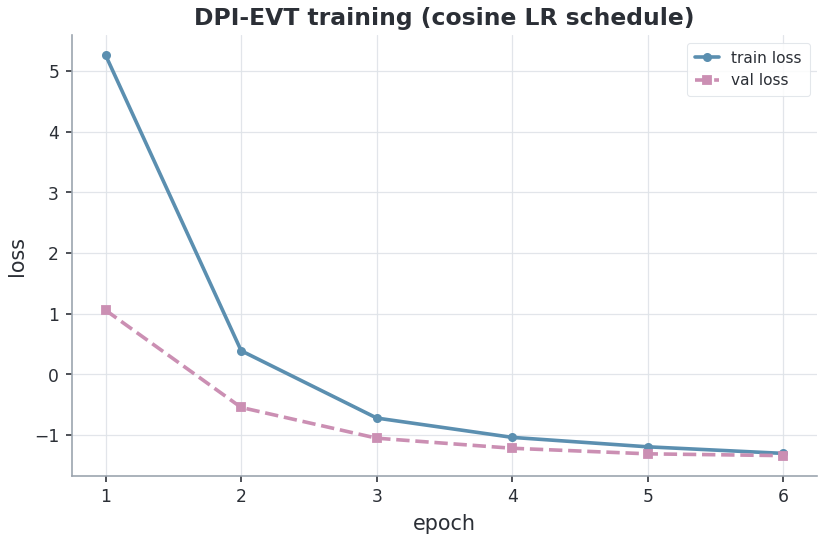

In [4]:
from liquefaction_ai.viz import new_figure, save_figure, QUALITATIVE, GRID
figw, fig = new_figure((7.4, 4.4)); ax = fig.add_subplot(111)
ax.plot(history["epoch"], history["train_loss"], "-o", color=QUALITATIVE[0], label="train loss", markersize=4)
ax.plot(history["epoch"], history["val_loss"], "--s", color="#CB8FB3", label="val loss", markersize=4)
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
if "val_AUROC" in history.columns:
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(history["epoch"], history["val_AUROC"], "-^", color="#7FB286", label="val AUROC", markersize=4)
    ax2.set_ylabel("val AUROC"); ax2.set_ylim(0.9, 1.0)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="center right")
else:
    ax.legend(fontsize=8.5)
ax.set_title("DPI-EVT training (cosine LR schedule)")
save_figure(figw, "2_4_dpi_evt_training", SAVE_FIGS)
figw

## Шаг 4. Калибровка интервалов и оценка на тесте

`fit_interval_scale` подбирает масштаб ширины интервалов по валидации (целевое покрытие 90 %).
Затем считаем полный набор метрик на тестовой выборке.

In [5]:
calib_scale = fit_interval_scale(model, val, config, device, level=0.90)
metrics, _ = compute_metrics("DPI-EVT", collect_outputs(model, test, config, device), test, config)
keys = [("PPR Traj_RMSE", "Traj_RMSE"), ("Traj CRPS", "Traj_CRPS"), ("Calibration err", "Calibration_Error"),
        ("AUROC", "AUROC"), ("Brier", "Brier"), ("Physics violation", "Physics_Violation_Rate"),
        ("N_liq logMAE", "N_liq_logMAE"), ("N_liq MAE", "N_liq_MAE"), ("CRR RMSE", "CRR_RMSE")]
display(pd.DataFrame({"Metric": [k for k, _ in keys],
                      "DPI-EVT": [round(float(metrics[v]), 4) if metrics[v] == metrics[v] else None for _, v in keys]}))
print("calib_scale:", round(float(calib_scale), 3))

,Metric,DPI-EVT
0,PPR Traj_RMSE,0.1170
1,Traj CRPS,0.0591
2,Calibration err,0.0354
3,AUROC,0.9996
4,Brier,0.0163
5,Physics violation,0.0000
6,N_liq logMAE,0.5697
7,N_liq MAE,307.4850
8,CRR RMSE,0.1232


calib_scale: 0.7


## Шаг 5. Сохранение модели

Сохраняем веса, гиперпараметры (с `calib_scale`) и историю — в том же формате, что и остальные
модели, поэтому ноутбуки оценки серии 3 подхватывают DPI-EVT автоматически.

In [6]:
hp = {"model_type": "DPIEvtNet", "display_name": "DPI-EVT", "model_kwargs": model_kwargs}
write_hyperparams(MODELS_DIR, "dpi_evt", hp)
save_trained_model(model, MODELS_DIR, "dpi_evt", {**hp, "epochs": EPOCHS, "calib_scale": float(calib_scale)}, history)
print("DPI-EVT сохранён в", MODELS_DIR / "dpi_evt")

DPI-EVT сохранён в /sessions/zealous-kind-sagan/mnt/liquefaction-ai/models/dpi_evt


## Итог

DPI-EVT обучен штатно (косинусный LR, развязанная CRR, N_liq из кривой), откалиброван и
сохранён в `models/dpi_evt`. Теперь он воспроизводимо входит в пайплайн: после `2_1`–`2_3`
запустите этот ноутбук — и серия `3_*` оценит полный набор моделей, включая DPI-EVT как
флагман (лучший N_liq и нулевые физические нарушения).

Запускать после смены датасета (ноутбук `1_0`) или при пустой папке `models/`.